# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   **NSL-KDD** adalah dataset yang dirancang untuk mengatasi beberapa kelemahan inheren yang ada pada dataset pendahulunya, yaitu KDD'99. Dataset ini sangat populer digunakan dalam penelitian evaluasi sistem deteksi intrusi jaringan (Network Intrusion Detection System atau NIDS) berbasis mesin pembelajaran (machine learning). 
   sumber dataset ada di https://www.kaggle.com/datasets/hassan06/nslkdd/data 

   Dataset ini disediakan dalam dua format utama: .TXT (format teks/CSV standar) dan .ARFF (format file atribut yang biasa digunakan pada software data mining seperti WEKA) dan yang digunakan di project ini adalah format TXT. Dataset ini terbagi menjadi beberapa bagian berkas untuk kebutuhan pelatihan (training) dan pengujian (testing):

   - **KDDTrain+.TXT** : Kumpulan data penuh untuk pelatihan yang mencakup label jenis serangan (attack-type) dan tingkat kesulitan (difficulty level).
   - **KDDTest+.TXT** : Kumpulan data penuh untuk pengujian model.

   Dataset NSL-KDD memiliki 41 fitur utama yang menangkap karakteristik dari koneksi jaringan, ditambah dengan 1 fitur target/label. Berdasarkan strukturnya, fitur-fitur tersebut dikelompokkan ke dalam beberapa tipe:

   a. **Fitur Dasar Koneksi (Basic Features)** adalah Fitur yang diekstrak langsung dari enkapsulasi protokol (TCP/IP):
   - *duration*: Durasi koneksi dalam satuan detik (tipe: kontinu/real).
   - *protocol_type*: Jenis protokol yang digunakan, bernilai kategorikal: tcp, udp, atau icmp.
   - *service*: Jenis layanan jaringan pada tujuan, seperti http, smtp, ftp, ftp_data, private, pop_3, telnet, dsb.
   - *flag*: Status normal atau error dari koneksi, seperti SF (Normal), S0, REJ, RSTO, RSTR, dsb.
   - *src_bytes*: Jumlah byte data yang dikirim dari sumber ke tujuan.
   - *dst_bytes*: Jumlah byte data yang diterima oleh sumber dari tujuan.
   - *land*: Nilai biner (0 atau 1). Bernilai 1 jika source dan destination IP serta port-nya sama (indikasi serangan Land).
   - *wrong_fragment*: Jumlah fragmen yang salah/rusak dalam koneksi.
   - *urgent*: Jumlah paket mendesak (urgent packets).

   b. **Fitur Konten (Content Features)** adalah Fitur yang digunakan untuk mendeteksi perilaku mencurigakan di dalam muatan data (terutama untuk serangan tipe U2R dan R2L):
   - *hot*: Jumlah indikator internal yang bernilai "hot" (seperti akses ke file/direktori tertentu).
   - *num_failed_logins*: Jumlah percobaan login yang gagal.
   - *logged_in*: Status biner (0 atau 1), menunjukkan apakah user berhasil login atau tidak.
   - *num_compromised*: Jumlah kondisi compromised (terancam/diretas).
   - *root_shell*: Bernilai 1 jika root shell berhasil didapatkan; 0 jika tidak.
   - *su_attempted*: Status percobaan perintah su root.
   - *num_root*: Jumlah akses pengguna sebagai root.
   - *num_file_creations*: Jumlah operasi pembuatan file baru.
   - *num_shells*: Jumlah shell prompt yang dibuka.
   - *num_access_files*: Jumlah operasi pada file kontrol akses.
   - *num_outbound_cmds*: Jumlah perintah keluar dalam sesi FTP.
   - *is_host_login*: Apakah login dilakukan sebagai admin/host.
   - *is_guest_login*: Apakah login menggunakan akun tamu (guest).

   c. **Fitur Lalu Lintas Berbasis Waktu (Time-based Traffic Features)** adalah Fitur statistik yang diperiksa dalam jendela waktu berdurasi 2 detik:
   - *count*: Jumlah koneksi ke host tujuan yang sama dengan koneksi saat ini dalam kurun waktu 2 detik terakhir.
   - *srv_count*: Jumlah koneksi yang memiliki layanan (service) yang sama dalam 2 detik terakhir.
   - *serror_rate & srv_serror_rate*: Persentase koneksi yang memicu error "SYN"
   - *rerror_rate & srv_rerror_rate*: Persentase koneksi yang memicu error "REJ" (ditolak).
   - *same_srv_rate*: Persentase koneksi ke layanan yang sama di antara koneksi yang dihitung di fitur count.
   - *diff_srv_rate*: Persentase koneksi ke layanan yang berbeda.
   - *srv_diff_host_rate*: Persentase koneksi ke host tujuan yang berbeda pada layanan yang sama.

   d. **Fitur Lalu Lintas Berbasis Host (Host-based Traffic Features)** adalah Fitur statistik untuk menilai pola serangan yang lambat atau tersebar (seperti port scanning jarak jauh yang melewati batas waktu jendela 2 detik):
   - Menggunakan parameter tujuan seperti *dst_host_count, dst_host_srv_count*.
   - Menghitung rasio error dan rasio kesamaan layanan berbasis host tujuan, misalnya *dst_host_same_srv_rate, dst_host_diff_srv_rate, dst_host_serror_rate, dan dst_host_rerror_rate*.

   e. **Fitur Target / Label Klasifikasi**
   - *outcome*: Label akhir yang mendefinisikan sifat koneksi, apakah berupa jaringan *normal* atau *attack* (serangan/intrusi).

# **2. Import Library**



Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
# load dataset yang digunakan untuk eksperimen
df = pd.read_csv("KDDTrain+.txt", header=None)
df.head()

,0,1,2,3,4,5,6,7,8,9,...,33,34,35,36,37,38,39,40,41,42
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [3]:
#melakukan eksplorasi data
print("Jumlah baris dan kolom:", df.shape)

Jumlah baris dan kolom: (125973, 43)


In [4]:
# mapping nama kolom atau fitur pada dataset
columns = (['duration','protocol_type','service','flag','src_bytes','dst_bytes','land','wrong_fragment','urgent','hot'
,'num_failed_logins','logged_in','num_compromised','root_shell','su_attempted','num_root','num_file_creations'
,'num_shells','num_access_files','num_outbound_cmds','is_host_login','is_guest_login','count','srv_count','serror_rate'
,'srv_serror_rate','rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate','srv_diff_host_rate','dst_host_count','dst_host_srv_count'
,'dst_host_same_srv_rate','dst_host_diff_srv_rate','dst_host_same_src_port_rate','dst_host_srv_diff_host_rate','dst_host_serror_rate'
,'dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate','outcome','level'])
df.columns = columns
# menampilkan nama kolom atau fitur pada dataset
print("\nNama kolom atau fitur pada dataset:")
print(df.columns)


Nama kolom atau fitur pada dataset:
Index(['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
       'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
       'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
       'num_access_files', 'num_outbound_cmds', 'is_host_login',
       'is_guest_login', 'count', 'srv_count', 'serror_rate',
       'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate', 'outcome', 'level'],
      dtype='object')


In [5]:
# melakukan eksplorasi data dengan melihat informasi dataset
print("\nInformasi dataset:")
print(df.info())



Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  object 
 2   service                      125973 non-null  object 
 3   flag                         125973 non-null  object 
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 no

In [6]:
df.describe().style.background_gradient(cmap='Blues').set_properties(**{'font-family':'Segoe UI'})

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,level
count,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000
mean,287.144650,45566.743000,19779.114421,0.000198,0.022687,0.000111,0.204409,0.001222,0.395736,0.279250,0.001342,0.001103,0.302192,0.012669,0.000413,0.004096,0.000000,0.000008,0.009423,84.107555,27.737888,0.284485,0.282485,0.119958,0.121183,0.660928,0.063053,0.097322,182.148945,115.653005,0.521242,0.082951,0.148379,0.032542,0.284452,0.278485,0.118832,0.120240,19.504060
std,2604.515310,5870331.181891,4021269.151440,0.014086,0.253530,0.014366,2.149968,0.045239,0.489010,23.942042,0.036603,0.045154,24.399618,0.483935,0.022181,0.099370,0.000000,0.002817,0.096612,114.508607,72.635840,0.446456,0.447022,0.320436,0.323647,0.439623,0.180314,0.259830,99.206213,110.702741,0.448949,0.188922,0.308997,0.112564,0.444784,0.445669,0.306557,0.319459,2.291503
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.090000,0.000000,0.000000,82.000000,10.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000
50%,0.000000,44.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,8.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,255.000000,63.000000,0.510000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000
75%,0.000000,276.000000,516.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,143.000000,18.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.060000,0.000000,255.000000,255.000000,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000,21.000000
max,42908.000000,1379963888.000000,1309937401.000000,1.000000,3.000000,3.000000,77.000000,5.000000,1.000000,7479.000000,1.000000,2.000000,7468.000000,43.000000,2.000000,9.000000,0.000000,1.000000,1.000000,511.000000,511.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,255.000000,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,21.000000


In [7]:
# melakukan eksplorasi data dengan melihat distribusi kelas pada kolom 'outcome'
df.loc[df['outcome'] == "normal", "outcome"] = 'normal'
df.loc[df['outcome'] != "normal", "outcome"] = 'attack'
print("\nDistribusi kelas pada kolom 'outcome':")
print(df['outcome'].value_counts())


Distribusi kelas pada kolom 'outcome':
outcome
normal    67343
attack    58630
Name: count, dtype: int64


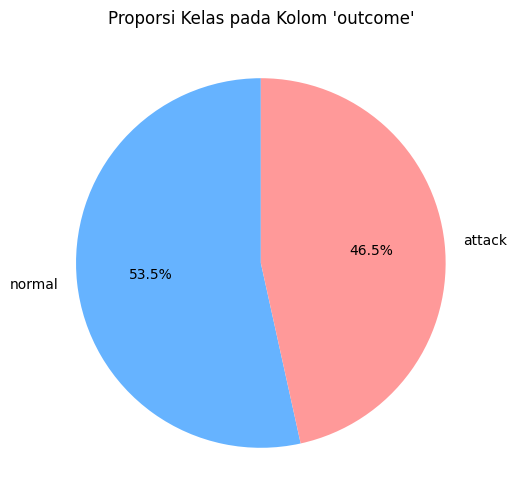

In [8]:
# membuat diagram lingkaran untuk melihat proporsi kelas pada kolom 'outcome'
plt.figure(figsize=(6, 6))
df['outcome'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, colors=['#66b3ff','#ff9999'])
plt.title("Proporsi Kelas pada Kolom 'outcome'")
plt.ylabel('')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [13]:
# import file automate_Rudy Eko Prasetya.py
from automate_preprocessing import preprocess
# melakukan preprocessing data dengan memanggil fungsi preprocess
df_clean = preprocess(df)

In [15]:
#liat data setelah di pre processing
df_clean.head()

,land,logged_in,is_host_login,is_guest_login,outcome,level,duration,src_bytes,dst_bytes,wrong_fragment,...,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
0,0,0,0,0,0,20,0.0,1.619565,0.000000,0.0,...,False,False,False,False,False,False,False,False,True,False
1,0,0,0,0,0,15,0.0,0.369565,0.000000,0.0,...,False,False,False,False,False,False,False,False,True,False
2,0,0,0,0,1,19,0.0,-0.159420,0.000000,0.0,...,False,False,False,False,True,False,False,False,False,False
3,0,1,0,0,0,21,0.0,0.681159,15.800388,0.0,...,False,False,False,False,False,False,False,False,True,False
4,0,1,0,0,0,21,0.0,0.561594,0.813953,0.0,...,False,False,False,False,False,False,False,False,True,False


In [14]:
#simpan dataset yang sudah dipreprocessing ke dalam file CSV dengan nama preprocessed_kdd.csv
df_clean.to_csv("preprocessed_kdd.csv", index=False)